# Projeto Integrador 3 - Clusterização

## Imports

In [19]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import Image

pd.set_option('display.max_columns', None)

## Data Load

In [4]:
conn = sqlite3.connect('../data/customer_data.db')

query = """
SELECT * 
FROM customer c 
LEFT JOIN products p ON c.ID = p.ID 
LEFT JOIN place pl ON c.ID  = pl.ID 
LEFT JOIN promotion pr ON c.ID = pr.ID 
"""

df = pd.read_sql_query(query,conn)

conn.close()

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,Complain,ID,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,ID,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,ID,NumDealsPurchases,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0,5524,635,88,546,172,88,88,5524,8,10,4,7,5524,3,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0,2174,11,1,6,2,1,6,2174,1,1,2,5,2174,2,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0,4141,426,49,127,111,21,42,4141,8,2,10,4,4141,1,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0,6182,11,4,20,10,3,5,6182,2,0,4,6,6182,2,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0,5324,173,43,118,46,27,15,5324,5,3,6,5,5324,5,0,0,0,0,0,0


## 1.0 Descrição dos Dados

In [6]:
df.shape

(2240, 30)

### 1.1 Tipo dos Dados

In [7]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
Complain                 int64
ID                       int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
ID                       int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
ID                       int64
NumDealsPurchases        int64
AcceptedCmp2             int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
Response                 int64
dtype: object

### 1.2 Check Na

In [8]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
Complain                0
ID                      0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
ID                      0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
ID                      0
NumDealsPurchases       0
AcceptedCmp2            0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
Response                0
dtype: int64

### 1.3 Chancce Data Type

In [9]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst = True, errors = 'coerce')

In [10]:
df.dropna(inplace = True)

### 1.4 Estatística Descritiva

In [11]:
num_attributes = df.select_dtypes(include = ['int64', 'float64', 'int32', 'float32'])

In [12]:
#medidas de tendência central:

ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T     #média
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T   #mediana

#medidas de dispersão:
d1 = pd.DataFrame(num_attributes.apply(np.std)).T                               #desvio-padrão
d2 = pd.DataFrame(num_attributes.apply(min)).T                                  #mínimo
d3 = pd.DataFrame(num_attributes.apply(max)).T                                  #máximo
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T          #range
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T                   #assimetria
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T               #curtose

#concatenar:
m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,ID,0.0,11191.0,11191.0,5588.353339,5458.5,3248.643030,0.040459,-1.189677
1,Year_Birth,1893.0,1996.0,103.0,1968.820397,1970.0,11.982849,-0.353661,0.734670
2,Income,1730.0,666666.0,664936.0,52247.251354,51381.5,25167.396174,6.763487,159.636700
3,Kidhome,0.0,2.0,2.0,0.441787,0.0,0.536775,0.635610,-0.791164
4,Teenhome,0.0,2.0,2.0,0.505415,0.0,0.544058,0.407553,-0.989619
5,Recency,0.0,99.0,99.0,49.012635,49.0,28.941819,0.001648,-1.199777
6,Complain,0.0,1.0,1.0,0.009477,0.0,0.096885,10.132737,100.763293
7,ID,0.0,11191.0,11191.0,5588.353339,5458.5,3248.643030,0.040459,-1.189677
8,MntWines,0.0,1493.0,1493.0,305.091606,174.5,337.251800,1.170720,0.582741
9,MntFruits,0.0,199.0,199.0,26.356047,8.0,39.784937,2.101658,4.054082


## 2.0 Feature Engineering

In [13]:
df2 = df.copy()

In [14]:
df2.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'Complain', 'ID', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'ID', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'ID', 'NumDealsPurchases',
       'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'Response'],
      dtype='object')

In [15]:
#Soma de todos os gastos que o cliente teve:

df2['Spent'] = (df2['MntWines'] + df2['MntFruits'] + df2['MntMeatProducts'] + 
                df2['MntFishProducts'] + df2['MntSweetProducts'] + df2['MntGoldProds'])

#Se tem filhos:
df2['Children'] = df2['Kidhome'] + df2['Teenhome']
df2['Is_Parent'] = np.where(df2.Children > 0, 1, 0)

#idade:
df2['Age'] = 2025 - df2['Year_Birth']

## 3.0 Análise Exploratória dos Dados

In [18]:
df3 = df2.copy()

### 3.1 Mapa Mental de Hipóteses

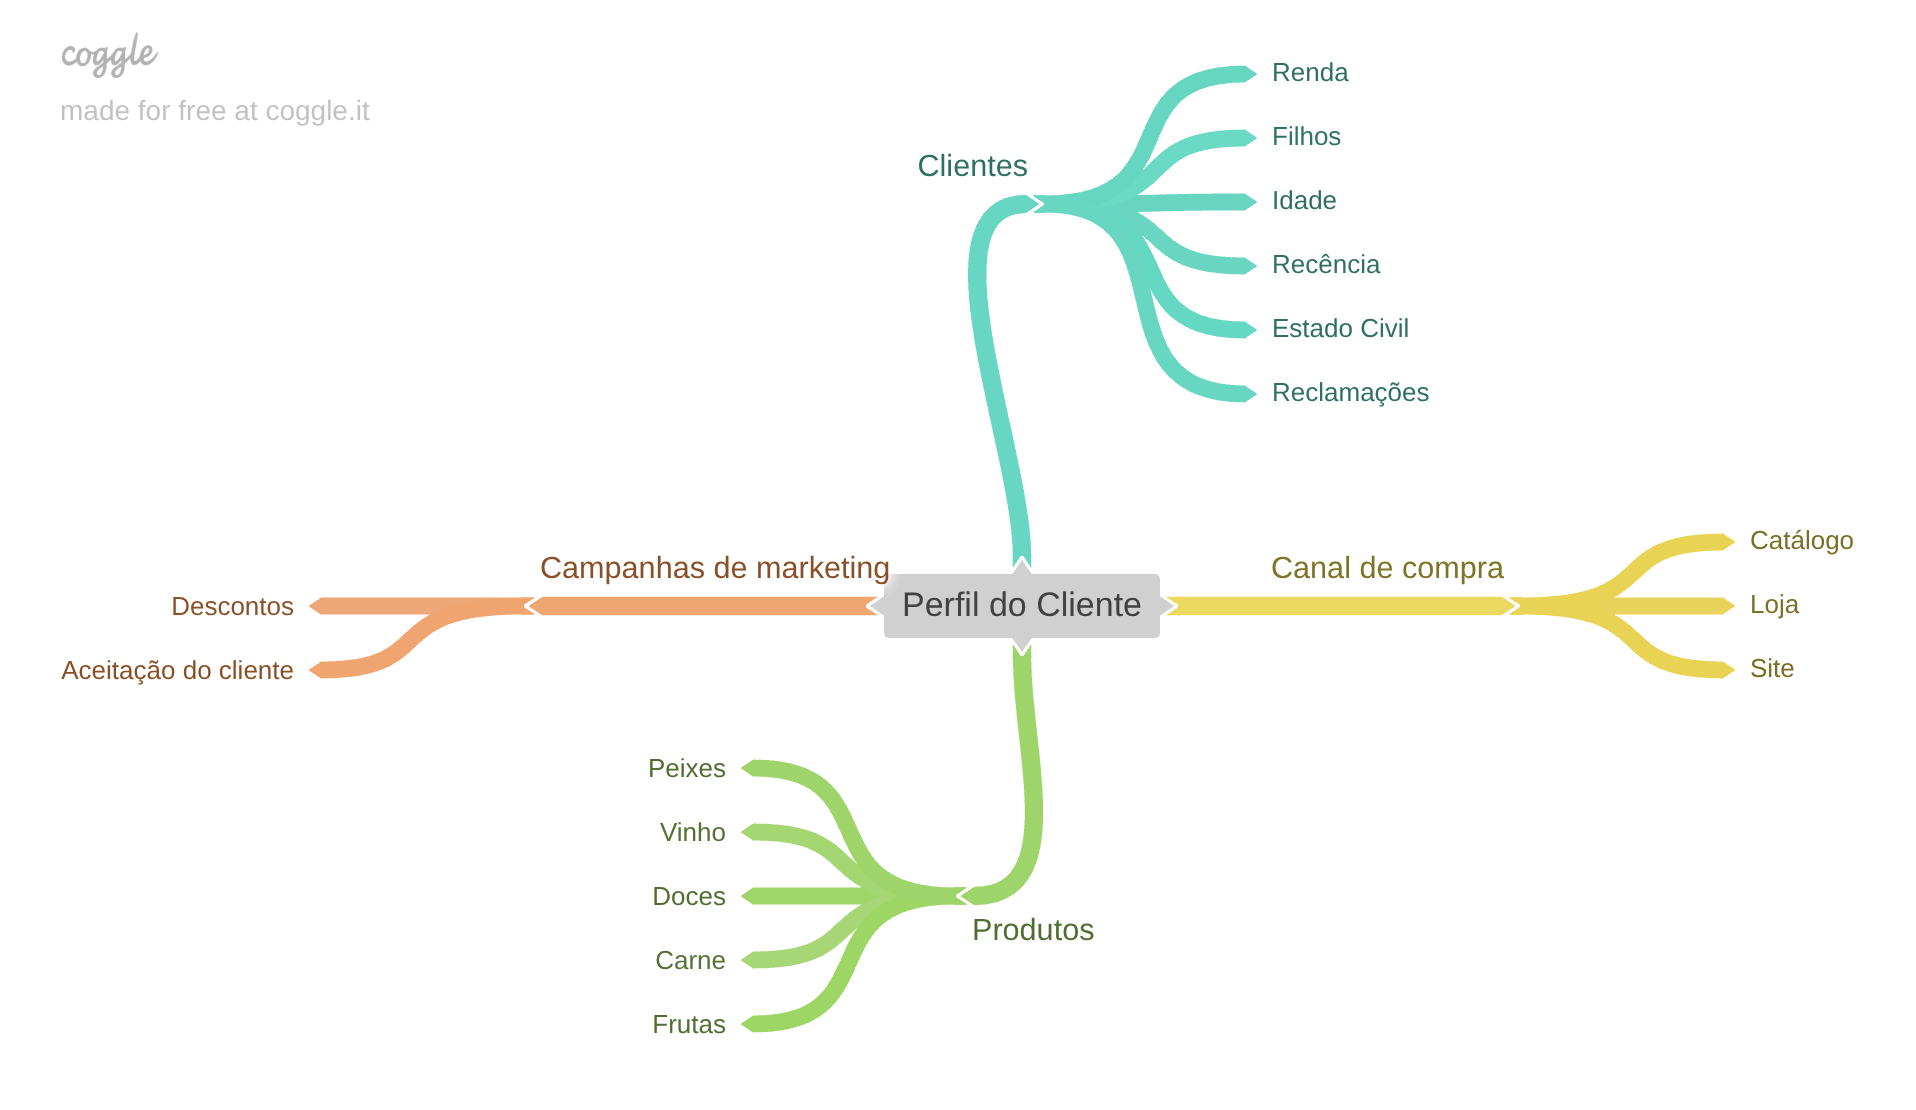

In [16]:
Image('Perfil_do_Cliente.png')

### 3.2 Análise Univariada

In [24]:
df3.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'Complain', 'ID', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'ID', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'ID', 'NumDealsPurchases',
       'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'Response', 'Spent', 'Children', 'Is_Parent', 'Age'],
      dtype='object')

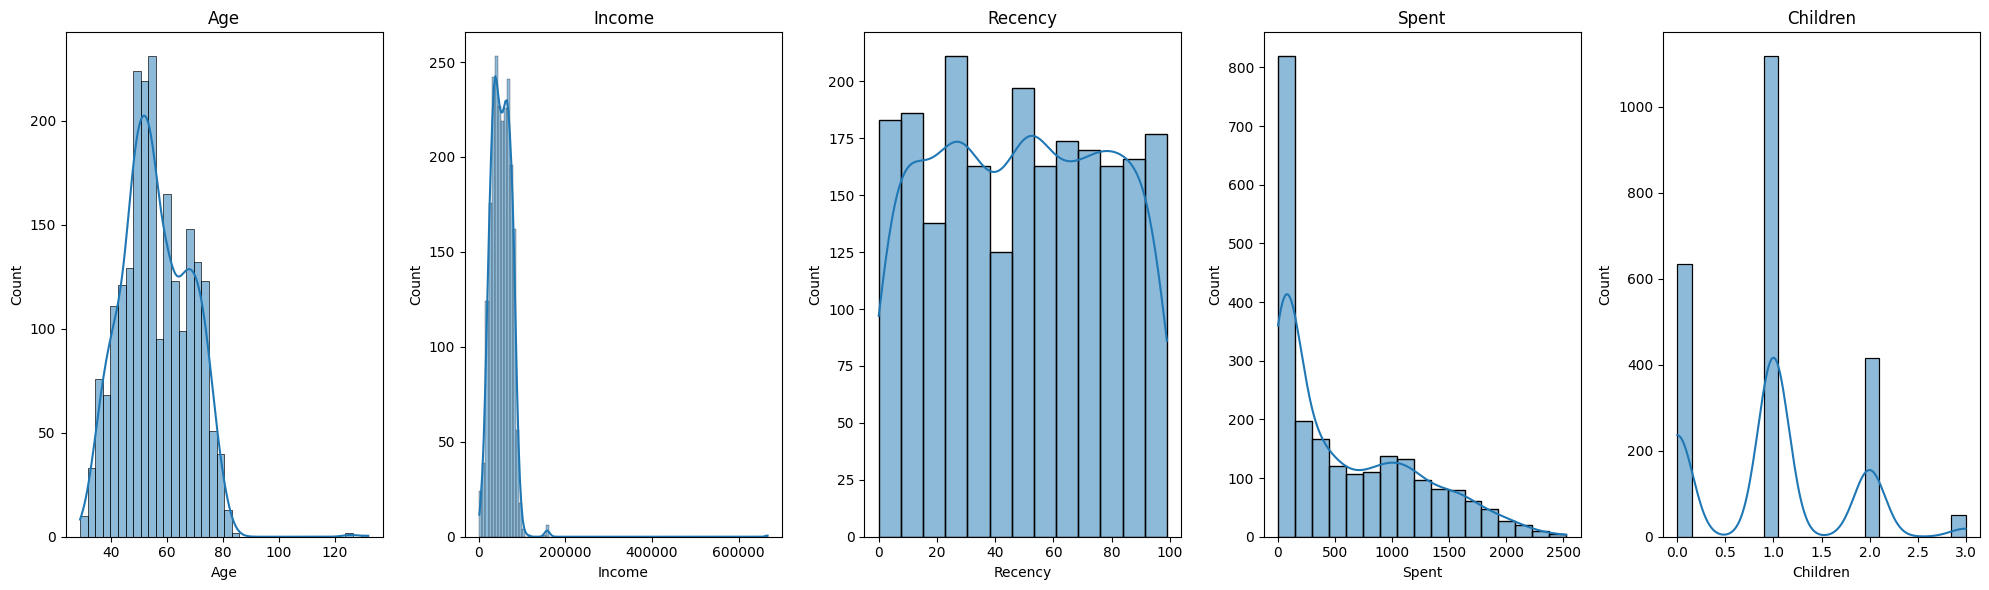

In [29]:
fig, axes = plt.subplots(1, 5, figsize = (20,6))

columns = ['Age', 'Income', 'Recency', 'Spent', 'Children']

for ax, col in zip(axes, columns):
    sns.histplot(df3[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()